# 08 — AII-Augmented Predictive Model

**Research question**: Do AI disclosure intensity (AII) and knowledge-graph (KG) signals
add predictive content for next-quarter WDAY return direction beyond price history alone?

**Price-only benchmark (notebook 07)**:
- Best model: Logistic Regression — test accuracy **0.8125**, test AUC **0.9048**
- Economic: LR long/cash strategy **77.5% cumulative / 10.0% annualized** (2020–2025)
- XGBoost underperforms on hold-out, suggesting regularized linear models suit the small-N regime

**Data provenance**:
- `wday_historical_data.csv` — WDAY quarterly OHLCV (yfinance)
- `data/processed/wday_modeling_dataset.csv` — pre-lagged AII features + split labels (notebook 06)
- `data/processed/quarterly_signals.csv` — KG signals (risk_density, product_coverage)

**Feature sets**:

| Set | Features | Count |
|-----|----------|-------|
| `PRICE_FEATURES` | log_return_lag1/2, vol_4q, mom_4q, ma_ratio | 5 |
| `AII_CORE` | aii_lag1, aii_delta_lag1 | 2 |
| `AII_FULL` | AII_CORE + aii_smooth_2q, bucket_generative_ai_lag1, risk_density_lag1, product_coverage_lag1 | 6 |
| `COMBINED_CORE` | PRICE_FEATURES + AII_CORE | 7 |
| `COMBINED_FULL` | PRICE_FEATURES + AII_FULL | 11 |

**Model variants** (6 total):
- AII-only: LR, XGB (ablation — pure disclosure signal)
- Price + Core AII: LR, XGB
- Price + Full AII: LR, XGB

**Evaluation protocol** (identical to notebooks 06 and 07):
- Train: 2015-Q1 – 2019-Q4 | Validation: 2020-Q1 – 2021-Q4 | Test: 2022-Q1 – 2025-Q4
- `TimeSeriesSplit(n_splits=5, gap=1)` for cross-validation on training set
- Hold-out metrics: accuracy and ROC-AUC on val and test independently
- Economic metric: long/cash strategy cumulative and annualized return (2020-Q1 – 2025-Q4)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    ConfusionMatrixDisplay, confusion_matrix,
)
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

print('Imports OK')

Imports OK


In [2]:
# Load WDAY price history and engineer all 5 leakage-safe price features
# Identical to notebook 07 cell 3 — ensures consistent feature engineering

RAW_CSV = 'wday_historical_data.csv'
wday_raw = pl.read_csv(RAW_CSV, try_parse_dates=True)

wday = (
    wday_raw
    .with_columns([
        pl.col('Date').cast(pl.Utf8).str.slice(0, 10).str.to_date('%Y-%m-%d').alias('date_parsed'),
    ])
    .with_columns([
        pl.col('date_parsed').dt.year().alias('year'),
        ((pl.col('date_parsed').dt.month() - 1) // 3 + 1).alias('quarter'),
    ])
    .sort(['year', 'quarter'])
)

wday = wday.with_columns([
    (pl.col('Close').log() - pl.col('Close').shift(1).log()).alias('log_return'),
])

wday = wday.with_columns([
    pl.col('log_return').rolling_std(window_size=4).alias('vol_4q_raw'),
    pl.col('log_return').rolling_sum(window_size=4).alias('mom_4q_raw'),
    pl.col('Close').rolling_mean(window_size=4).alias('ma_close_4q_raw'),
])

wday = wday.with_columns([
    pl.col('log_return').shift(1).alias('log_return_lag1'),
    pl.col('log_return').shift(2).alias('log_return_lag2'),
    pl.col('vol_4q_raw').shift(1).alias('vol_4q'),
    pl.col('mom_4q_raw').shift(1).alias('mom_4q'),
    (pl.col('Close').shift(1) / pl.col('ma_close_4q_raw').shift(1)).alias('ma_ratio'),
])

wday = wday.with_columns([
    (pl.col('log_return') > 0).cast(pl.Int32).alias('Target'),
])

print(f'Price series rows: {len(wday)}')
print(f'Range: {wday["year"].min()}-Q{wday["quarter"].min()} '
      f'to {wday["year"].max()}-Q{wday["quarter"].max()}')

Price series rows: 53
Range: 2012-Q1 to 2025-Q4


In [3]:
# Load AII features (pre-lagged) and KG signals

modeling06 = pl.read_csv('../data/processed/wday_modeling_dataset.csv')

signals = pl.read_csv('../data/processed/quarterly_signals.csv')
# quarterly_signals.csv is consecutive from 2013-Q1 onward → shift(1) correctly aligns Q-1
signals = signals.sort(['year', 'quarter']).with_columns([
    pl.col('risk_density').shift(1).alias('risk_density_lag1'),
    pl.col('product_coverage').shift(1).alias('product_coverage_lag1'),
])

# Join price features with AII features (inner → keeps 2015-Q1 to 2025-Q4)
modeling = wday.join(
    modeling06.select(['year', 'quarter', 'split', 'aii_lag1', 'aii_delta_lag1',
                       'aii_source_period', 'bucket_generative_ai_lag1']),
    on=['year', 'quarter'],
    how='inner',
).join(
    signals.select(['year', 'quarter', 'risk_density_lag1', 'product_coverage_lag1']),
    on=['year', 'quarter'],
    how='left',
)

print(f'Rows after joins: {len(modeling)}')
print('Split distribution:')
print(modeling.group_by('split').agg(pl.count().alias('n')).sort('split'))
print()
print('Sample — AII and KG columns:')
print(modeling.select(['year', 'quarter', 'split', 'aii_lag1', 'aii_delta_lag1',
                        'risk_density_lag1', 'product_coverage_lag1']).head(6))

Rows after joins: 44
Split distribution:
shape: (3, 2)
┌───────┬─────┐
│ split ┆ n   │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ test  ┆ 16  │
│ train ┆ 20  │
│ val   ┆ 8   │
└───────┴─────┘

Sample — AII and KG columns:
shape: (6, 7)
┌──────┬─────────┬───────┬──────────┬────────────────┬───────────────────┬───────────────────────┐
│ year ┆ quarter ┆ split ┆ aii_lag1 ┆ aii_delta_lag1 ┆ risk_density_lag1 ┆ product_coverage_lag1 │
│ ---  ┆ ---     ┆ ---   ┆ ---      ┆ ---            ┆ ---               ┆ ---                   │
│ i32  ┆ i8      ┆ str   ┆ f64      ┆ f64            ┆ f64               ┆ f64                   │
╞══════╪═════════╪═══════╪══════════╪════════════════╪═══════════════════╪═══════════════════════╡
│ 2015 ┆ 1       ┆ train ┆ 0.042994 ┆ 0.000367       ┆ 10.0              ┆ 8.0                   │
│ 2015 ┆ 2       ┆ train ┆ 0.057484 ┆ 0.01449        ┆ 11.0              ┆ 8.0                   │
│ 2015 ┆ 3       ┆ train ┆ 0.0      ┆ -0.057484      ┆ 6.0      

In [4]:
# Compute 2-quarter smoothed AII (rolling mean of aii_lag1)
# Leakage-safe: aii_lag1 already references Q-1 data; rolling over it uses Q-1 and Q-2 AII

modeling = modeling.sort(['year', 'quarter']).with_columns([
    pl.col('aii_lag1').rolling_mean(window_size=2).alias('aii_smooth_2q'),
])

# Correlation matrix of all AII + KG features
aii_feature_cols = ['aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q',
                    'bucket_generative_ai_lag1', 'risk_density_lag1', 'product_coverage_lag1']

aii_df = modeling.select(aii_feature_cols).drop_nulls()
corr_mat = np.corrcoef(aii_df.to_numpy().T)

print('=== AII + KG Feature Correlation Matrix ===')
print(f'  {" ".join(f"{c[:12]:>13}" for c in aii_feature_cols)}')
for i, row_name in enumerate(aii_feature_cols):
    row_str = '  '.join(f'{corr_mat[i, j]:>6.3f}' for j in range(len(aii_feature_cols)))
    print(f'{row_name:<30} {row_str}')

print(f'\nRows with non-null aii_smooth_2q: '
      f'{modeling["aii_smooth_2q"].drop_nulls().len()} / {len(modeling)}')
print('(First row 2015-Q1 has null aii_smooth_2q — only 1 observation in 2q window)')

=== AII + KG Feature Correlation Matrix ===
       aii_lag1  aii_delta_la  aii_smooth_2  bucket_gener  risk_density  product_cove
aii_lag1                        1.000   0.284   0.965   0.320  -0.058   0.304
aii_delta_lag1                  0.284   1.000   0.022   0.180   0.083   0.154
aii_smooth_2q                   0.965   0.022   1.000   0.284  -0.083   0.274
bucket_generative_ai_lag1       0.320   0.180   0.284   1.000  -0.061  -0.108
risk_density_lag1              -0.058   0.083  -0.083  -0.061   1.000   0.503
product_coverage_lag1           0.304   0.154   0.274  -0.108   0.503   1.000

Rows with non-null aii_smooth_2q: 43 / 44
(First row 2015-Q1 has null aii_smooth_2q — only 1 observation in 2q window)


In [5]:
# Feature set definitions

PRICE_FEATURES = ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio']

AII_CORE = ['aii_lag1', 'aii_delta_lag1']

AII_FULL = [
    'aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q',
    'bucket_generative_ai_lag1',  # structural signal: generative AI emergence
    'risk_density_lag1',           # KG: risk disclosure breadth per document
    'product_coverage_lag1',       # KG: product mention breadth per document
]

COMBINED_CORE = PRICE_FEATURES + AII_CORE   # 7 features
COMBINED_FULL = PRICE_FEATURES + AII_FULL   # 11 features

print('Feature sets:')
print(f'  PRICE_FEATURES  ({len(PRICE_FEATURES)}): {PRICE_FEATURES}')
print(f'  AII_CORE        ({len(AII_CORE)}):  {AII_CORE}')
print(f'  AII_FULL        ({len(AII_FULL)}):  {AII_FULL}')
print(f'  COMBINED_CORE   ({len(COMBINED_CORE)}):  {COMBINED_CORE}')
print(f'  COMBINED_FULL   ({len(COMBINED_FULL)}): {COMBINED_FULL}')

print('\n=== AII + KG Feature Descriptive Statistics ===')
print(modeling.select(AII_FULL).drop_nulls().describe())

y_tmp = np.array(modeling['Target'])
split_tmp = np.array(modeling['split'])
print(f'\nClass balance (full 44 rows): {y_tmp.sum()} up / {(1-y_tmp).sum()} down '
      f'({y_tmp.mean():.1%} up)')

Feature sets:
  PRICE_FEATURES  (5): ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio']
  AII_CORE        (2):  ['aii_lag1', 'aii_delta_lag1']
  AII_FULL        (6):  ['aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q', 'bucket_generative_ai_lag1', 'risk_density_lag1', 'product_coverage_lag1']
  COMBINED_CORE   (7):  ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio', 'aii_lag1', 'aii_delta_lag1']
  COMBINED_FULL   (11): ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio', 'aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q', 'bucket_generative_ai_lag1', 'risk_density_lag1', 'product_coverage_lag1']

=== AII + KG Feature Descriptive Statistics ===
shape: (9, 7)
┌────────────┬──────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ statistic  ┆ aii_lag1 ┆ aii_delta_la ┆ aii_smooth_2 ┆ bucket_gener ┆ risk_density ┆ product_cove │
│ ---        ┆ ---      ┆ g1           ┆ q            ┆ ative_ai_lag ┆ _lag1       

In [6]:
# Leakage audit — verify all AII and KG features reference Q-1 or earlier

audit_cols = ['year', 'quarter', 'split', 'aii_source_period',
              'aii_lag1', 'aii_delta_lag1', 'risk_density_lag1', 'product_coverage_lag1']
train_audit = modeling.filter(pl.col('split') == 'train').select(audit_cols)

print('=== Leakage Audit: First 5 Training Rows ===')
print('aii_source_period must be Q-1 relative to (year, quarter).')
print('risk_density_lag1 must equal the Q-1 entry from quarterly_signals.csv.')
print(train_audit.head(5))

# Spot-check 2015-Q1
row_q1 = modeling.filter((pl.col('year') == 2015) & (pl.col('quarter') == 1))
signals_raw = pl.read_csv('../data/processed/quarterly_signals.csv')
q4_2014 = signals_raw.filter((pl.col('year') == 2014) & (pl.col('quarter') == 4))

print(f'\n=== 2015-Q1 Spot-Check ===')
print(f'  aii_source_period:           {row_q1["aii_source_period"][0]}  (expect: 2014-Q4)')
print(f'  aii_lag1:                    {row_q1["aii_lag1"][0]:.6f}')
print(f'  2014-Q4 risk_density (raw):  {q4_2014["risk_density"][0]}')
print(f'  risk_density_lag1 in model:  {row_q1["risk_density_lag1"][0]}')
print(f'  Match: {float(q4_2014["risk_density"][0]) == float(row_q1["risk_density_lag1"][0])}')

print('\n=== Leakage Summary ===')
leakage_table = [
    ('aii_lag1',                'wday_modeling_dataset.csv', 'Pre-lagged: aii_source_period=Q-1', 'SAFE'),
    ('aii_delta_lag1',          'wday_modeling_dataset.csv', 'Delta of Q-1 vs Q-2 AII',           'SAFE'),
    ('aii_smooth_2q',           'Computed in notebook',      '2q rolling mean of aii_lag1',        'SAFE'),
    ('bucket_generative_ai_lag1','wday_modeling_dataset.csv','Pre-lagged',                         'SAFE'),
    ('risk_density_lag1',       'quarterly_signals + shift', 'shift(1) on sorted Q series',        'SAFE'),
    ('product_coverage_lag1',   'quarterly_signals + shift', 'shift(1) on sorted Q series',        'SAFE'),
]
print(f'{"Feature":<30} {"Source":<28} {"Lag mechanism":<34} {"Status"}')
print('-' * 100)
for feat, src, mech, status in leakage_table:
    print(f'{feat:<30} {src:<28} {mech:<34} {status}')

=== Leakage Audit: First 5 Training Rows ===
aii_source_period must be Q-1 relative to (year, quarter).
risk_density_lag1 must equal the Q-1 entry from quarterly_signals.csv.
shape: (5, 8)
┌──────┬─────────┬───────┬───────────────┬──────────┬───────────────┬───────────────┬──────────────┐
│ year ┆ quarter ┆ split ┆ aii_source_pe ┆ aii_lag1 ┆ aii_delta_lag ┆ risk_density_ ┆ product_cove │
│ ---  ┆ ---     ┆ ---   ┆ riod          ┆ ---      ┆ 1             ┆ lag1          ┆ rage_lag1    │
│ i32  ┆ i8      ┆ str   ┆ ---           ┆ f64      ┆ ---           ┆ ---           ┆ ---          │
│      ┆         ┆       ┆ str           ┆          ┆ f64           ┆ f64           ┆ f64          │
╞══════╪═════════╪═══════╪═══════════════╪══════════╪═══════════════╪═══════════════╪══════════════╡
│ 2015 ┆ 1       ┆ train ┆ 2014-Q4       ┆ 0.042994 ┆ 0.000367      ┆ 10.0          ┆ 8.0          │
│ 2015 ┆ 2       ┆ train ┆ 2015-Q1       ┆ 0.057484 ┆ 0.01449       ┆ 11.0          ┆ 8.0          │
│ 2

In [7]:
# Drop nulls and create numpy arrays
# drop_nulls on COMBINED_FULL removes 2015-Q1 (null aii_smooth_2q)

modeling_clean = modeling.drop_nulls(subset=COMBINED_FULL)

print(f'Rows after drop_nulls(COMBINED_FULL): {len(modeling_clean)} (was {len(modeling)})')
print('Dropped rows: 2015-Q1 (null aii_smooth_2q — first row of rolling window)')

y_cls = np.array(modeling_clean['Target'])
y_reg = np.array(modeling_clean['log_return'])
split_col = np.array(modeling_clean['split'])

mask_train = split_col == 'train'
mask_val   = split_col == 'val'
mask_test  = split_col == 'test'

# Pre-compute feature arrays for all feature sets
X_price        = np.array(modeling_clean.select(PRICE_FEATURES))
X_aii_core     = np.array(modeling_clean.select(AII_CORE))
X_combined_core = np.array(modeling_clean.select(COMBINED_CORE))
X_combined_full = np.array(modeling_clean.select(COMBINED_FULL))

y_train = y_cls[mask_train]
y_val   = y_cls[mask_val]
y_test  = y_cls[mask_test]

print(f'\nSplit sizes — Train: {mask_train.sum()}  Val: {mask_val.sum()}  Test: {mask_test.sum()}')
print(f'Note: Train = 19 rows (was 20 in nb07; 2015-Q1 dropped due to aii_smooth_2q null)')

print('\nClass balance per split:')
for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name}: {y.sum()} up / {len(y)-y.sum()} down ({y.mean():.1%} up)')

Rows after drop_nulls(COMBINED_FULL): 43 (was 44)
Dropped rows: 2015-Q1 (null aii_smooth_2q — first row of rolling window)

Split sizes — Train: 19  Val: 8  Test: 16
Note: Train = 19 rows (was 20 in nb07; 2015-Q1 dropped due to aii_smooth_2q null)

Class balance per split:
  train: 10 up / 9 down (52.6% up)
  val: 6 up / 2 down (75.0% up)
  test: 9 up / 7 down (56.2% up)


In [8]:
# TimeSeriesSplit CV setup — same configuration as notebooks 06 and 07

tscv = TimeSeriesSplit(n_splits=5, gap=1)

print(f'TimeSeriesSplit: n_splits=5, gap=1')
print(f'Training set: {mask_train.sum()} rows (2015-Q2 to 2019-Q4)')
print()
print('Fold index ranges:')
for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_price[mask_train]), start=1):
    print(f'  Fold {fold}: train [{tr_idx[0]}–{tr_idx[-1]}] ({len(tr_idx)} rows)  '
          f'val [{vl_idx[0]}–{vl_idx[-1]}] ({len(vl_idx)} rows)')

# Helper factories (ensure identical hyperparameters across all cells)
def make_lr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ])

def make_xgb():
    return XGBClassifier(
        objective='binary:logistic', n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42, eval_metric='logloss', verbosity=0,
    )

print('\nHelper functions make_lr() and make_xgb() defined.')

TimeSeriesSplit: n_splits=5, gap=1
Training set: 19 rows (2015-Q2 to 2019-Q4)

Fold index ranges:
  Fold 1: train [0–2] (3 rows)  val [4–6] (3 rows)
  Fold 2: train [0–5] (6 rows)  val [7–9] (3 rows)
  Fold 3: train [0–8] (9 rows)  val [10–12] (3 rows)
  Fold 4: train [0–11] (12 rows)  val [13–15] (3 rows)
  Fold 5: train [0–14] (15 rows)  val [16–18] (3 rows)

Helper functions make_lr() and make_xgb() defined.


In [9]:
# Ablation: AII-only models (no price features)
# Purpose: isolate the pure disclosure signal independent of price momentum

X_train_aii = X_aii_core[mask_train]

cv_lr_aii  = cross_validate(make_lr(),  X_train_aii, y_train, cv=tscv, scoring=['accuracy'])
cv_xgb_aii = cross_validate(make_xgb(), X_train_aii, y_train, cv=tscv, scoring=['accuracy'])

lr_aii_acc  = cv_lr_aii['test_accuracy']
xgb_aii_acc = cv_xgb_aii['test_accuracy']

print('=== AII-Only Cross-Validation (n_splits=5, gap=1) ===')
print(f'  LR  folds: {np.round(lr_aii_acc, 3).tolist()}')
print(f'  LR  mean: {lr_aii_acc.mean():.4f}  std: {lr_aii_acc.std():.4f}')
print()
print(f'  XGB folds: {np.round(xgb_aii_acc, 3).tolist()}')
print(f'  XGB mean: {xgb_aii_acc.mean():.4f}  std: {xgb_aii_acc.std():.4f}')
print()
print('Interpretation:')
print('  AII features alone (no price) — measures disclosure-driven predictive content')
print(f'  Features: {AII_CORE}')

=== AII-Only Cross-Validation (n_splits=5, gap=1) ===
  LR  folds: [0.667, 0.0, 0.667, 0.0, 0.667]
  LR  mean: 0.4000  std: 0.3266

  XGB folds: [0.667, 0.0, 0.667, 0.0, 0.333]
  XGB mean: 0.3333  std: 0.2981

Interpretation:
  AII features alone (no price) — measures disclosure-driven predictive content
  Features: ['aii_lag1', 'aii_delta_lag1']


In [10]:
# Price + Core AII cross-validation

X_train_ccore = X_combined_core[mask_train]

cv_lr_ccore  = cross_validate(make_lr(),  X_train_ccore, y_train, cv=tscv, scoring=['accuracy'])
cv_xgb_ccore = cross_validate(make_xgb(), X_train_ccore, y_train, cv=tscv, scoring=['accuracy'])

lr_ccore_acc  = cv_lr_ccore['test_accuracy']
xgb_ccore_acc = cv_xgb_ccore['test_accuracy']

print('=== Price + Core AII Cross-Validation (n_splits=5, gap=1) ===')
print(f'  Features: {COMBINED_CORE}')
print()
print(f'  LR  folds: {np.round(lr_ccore_acc, 3).tolist()}')
print(f'  LR  mean: {lr_ccore_acc.mean():.4f}  std: {lr_ccore_acc.std():.4f}')
print()
print(f'  XGB folds: {np.round(xgb_ccore_acc, 3).tolist()}')
print(f'  XGB mean: {xgb_ccore_acc.mean():.4f}  std: {xgb_ccore_acc.std():.4f}')

# Reference: nb07 LR price-only CV was 0.5333 (20 training rows)
print()
print('[nb07 reference] LR Price-Only CV mean: 0.5333 ± 0.1633 (20 training rows)')
print(f'  LR Price+CoreAII delta vs nb07: {lr_ccore_acc.mean() - 0.5333:+.4f}')

=== Price + Core AII Cross-Validation (n_splits=5, gap=1) ===
  Features: ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio', 'aii_lag1', 'aii_delta_lag1']

  LR  folds: [0.667, 0.667, 0.667, 0.0, 0.333]
  LR  mean: 0.4667  std: 0.2667

  XGB folds: [0.667, 0.0, 0.667, 0.667, 0.333]
  XGB mean: 0.4667  std: 0.2667

[nb07 reference] LR Price-Only CV mean: 0.5333 ± 0.1633 (20 training rows)
  LR Price+CoreAII delta vs nb07: -0.0666


In [11]:
# Price + Full AII cross-validation

X_train_cfull = X_combined_full[mask_train]

cv_lr_cfull  = cross_validate(make_lr(),  X_train_cfull, y_train, cv=tscv, scoring=['accuracy'])
cv_xgb_cfull = cross_validate(make_xgb(), X_train_cfull, y_train, cv=tscv, scoring=['accuracy'])

lr_cfull_acc  = cv_lr_cfull['test_accuracy']
xgb_cfull_acc = cv_xgb_cfull['test_accuracy']

print('=== Price + Full AII Cross-Validation (n_splits=5, gap=1) ===')
print(f'  Features ({len(COMBINED_FULL)}): {COMBINED_FULL}')
print(f'  Training rows: {mask_train.sum()}  →  p/n ratio = {len(COMBINED_FULL)}/{mask_train.sum()} '
      f'({len(COMBINED_FULL)/mask_train.sum():.2f}) — regularization critical')
print()
print(f'  LR  folds: {np.round(lr_cfull_acc, 3).tolist()}')
print(f'  LR  mean: {lr_cfull_acc.mean():.4f}  std: {lr_cfull_acc.std():.4f}')
print()
print(f'  XGB folds: {np.round(xgb_cfull_acc, 3).tolist()}')
print(f'  XGB mean: {xgb_cfull_acc.mean():.4f}  std: {xgb_cfull_acc.std():.4f}')

print('\n=== CV Summary: All Variants ===')
print(f'{"Variant":<30} {"LR CV Acc":>12} {"XGB CV Acc":>12}')
print('-' * 58)
variants_cv = [
    ('AII-Only',        lr_aii_acc,   xgb_aii_acc),
    ('Price + Core AII', lr_ccore_acc, xgb_ccore_acc),
    ('Price + Full AII', lr_cfull_acc, xgb_cfull_acc),
]
for name, lr_acc, xgb_acc in variants_cv:
    print(f'{name:<30} {lr_acc.mean():.4f}±{lr_acc.std():.4f} {xgb_acc.mean():>12.4f}±{xgb_acc.std():.4f}')
print(f'[nb07 ref] Price-Only (20 rows){0.5333:>12.4f}±{0.1633:.4f} {0.4000:>12.4f}±{0.2494:.4f}')

=== Price + Full AII Cross-Validation (n_splits=5, gap=1) ===
  Features (11): ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio', 'aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q', 'bucket_generative_ai_lag1', 'risk_density_lag1', 'product_coverage_lag1']
  Training rows: 19  →  p/n ratio = 11/19 (0.58) — regularization critical

  LR  folds: [0.667, 0.667, 0.667, 0.0, 0.667]
  LR  mean: 0.5333  std: 0.2667

  XGB folds: [0.667, 0.0, 0.667, 0.667, 0.333]
  XGB mean: 0.4667  std: 0.2667

=== CV Summary: All Variants ===
Variant                           LR CV Acc   XGB CV Acc
----------------------------------------------------------
AII-Only                       0.4000±0.3266       0.3333±0.2981
Price + Core AII               0.4667±0.2667       0.4667±0.2667
Price + Full AII               0.5333±0.2667       0.4667±0.2667
[nb07 ref] Price-Only (20 rows)      0.5333±0.1633       0.4000±0.2494


In [12]:
# Hold-out evaluation: fit all 6 variants on full training set, evaluate on val and test

def eval_model(model, X_tr, y_tr, X_vl, y_vl, X_ts, y_ts):
    """Fit on training, return accuracy and AUC for val and test."""
    model.fit(X_tr, y_tr)
    vp = model.predict(X_vl)
    tp = model.predict(X_ts)
    try:
        v_auc = roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
        t_auc = roc_auc_score(y_ts, model.predict_proba(X_ts)[:, 1])
    except Exception:
        v_auc = t_auc = float('nan')
    return {
        'val_acc':  accuracy_score(y_vl, vp),
        'val_auc':  v_auc,
        'test_acc': accuracy_score(y_ts, tp),
        'test_auc': t_auc,
        'model':    model,
    }

X_val_aii    = X_aii_core[mask_val];       X_test_aii    = X_aii_core[mask_test]
X_val_ccore  = X_combined_core[mask_val];  X_test_ccore  = X_combined_core[mask_test]
X_val_cfull  = X_combined_full[mask_val];  X_test_cfull  = X_combined_full[mask_test]

specs = [
    ('LR  AII-Only',       make_lr(),  X_train_aii,   X_val_aii,   X_test_aii),
    ('XGB AII-Only',       make_xgb(), X_train_aii,   X_val_aii,   X_test_aii),
    ('LR  Price+CoreAII',  make_lr(),  X_train_ccore, X_val_ccore, X_test_ccore),
    ('XGB Price+CoreAII',  make_xgb(), X_train_ccore, X_val_ccore, X_test_ccore),
    ('LR  Price+FullAII',  make_lr(),  X_train_cfull, X_val_cfull, X_test_cfull),
    ('XGB Price+FullAII',  make_xgb(), X_train_cfull, X_val_cfull, X_test_cfull),
]

fitted = {}
results = {}
for name, model, Xtr, Xvl, Xts in specs:
    r = eval_model(model, Xtr, y_train, Xvl, y_val, Xts, y_test)
    results[name] = r
    fitted[name]  = r.pop('model')

# Majority baseline
maj_val_acc  = accuracy_score(y_val,  np.ones(len(y_val),  dtype=int))
maj_test_acc = accuracy_score(y_test, np.ones(len(y_test), dtype=int))

# Consolidated benchmark table
NB07 = {
    '[07] LR Price-Only*':  {'val_acc': 0.6250, 'val_auc': 0.0000, 'test_acc': 0.8125, 'test_auc': 0.9048},
    '[07] XGB Price-Only*': {'val_acc': 0.3750, 'val_auc': 0.0833, 'test_acc': 0.5000, 'test_auc': 0.5556},
    'Majority baseline':    {'val_acc': maj_val_acc, 'val_auc': 0.500, 'test_acc': maj_test_acc, 'test_auc': 0.500},
}

GATE_ACC = 0.8125
GATE_AUC = 0.9048

print('=== Consolidated Hold-out Benchmark Table ===')
print('* = imported from notebook 07 (fitted on 20 training rows; 2015-Q1 included)')
print()
hdr = f'{"Model":<26} {"Val Acc":>8} {"Val AUC":>8} {"Test Acc":>9} {"Test AUC":>9}  {"Beat 07?"}'
sep = '-' * 74
print(hdr)
print(sep)
for name, m in NB07.items():
    print(f'{name:<26} {m["val_acc"]:>8.4f} {m["val_auc"]:>8.4f} {m["test_acc"]:>9.4f} {m["test_auc"]:>9.4f}')
print(sep)
for name, m in results.items():
    beat = ('✓ acc' if m['test_acc'] > GATE_ACC else '    ') + \
           ('  ✓ auc' if m['test_auc'] > GATE_AUC else '')
    print(f'{name:<26} {m["val_acc"]:>8.4f} {m["val_auc"]:>8.4f} {m["test_acc"]:>9.4f} {m["test_auc"]:>9.4f}  {beat}')
print()
print(f'Gate: Test Acc > {GATE_ACC}, Test AUC > {GATE_AUC} (nb07 LR Price-Only benchmarks)')

=== Consolidated Hold-out Benchmark Table ===
* = imported from notebook 07 (fitted on 20 training rows; 2015-Q1 included)

Model                       Val Acc  Val AUC  Test Acc  Test AUC  Beat 07?
--------------------------------------------------------------------------
[07] LR Price-Only*          0.6250   0.0000    0.8125    0.9048
[07] XGB Price-Only*         0.3750   0.0833    0.5000    0.5556
Majority baseline            0.7500   0.5000    0.5625    0.5000
--------------------------------------------------------------------------
LR  AII-Only                 0.2500   0.2500    0.4375    0.4127      
XGB AII-Only                 0.2500   0.5833    0.4375    0.3571      
LR  Price+CoreAII            0.2500   0.4167    0.4375    0.5556      
XGB Price+CoreAII            0.3750   0.2083    0.4375    0.5714      
LR  Price+FullAII            0.2500   0.3333    0.4375    0.4921      
XGB Price+FullAII            0.7500   0.6667    0.5000    0.4603      

Gate: Test Acc > 0.8125, Test

=== Logistic Regression: Price + Full AII Coefficients ===
  (fitted on 19 training rows with StandardScaler)

Rank   Feature                         Coefficient Direction
------------------------------------------------------------------------
1      product_coverage_lag1                1.0048  positive → up signal
2      mom_4q                               0.9163  positive → up signal
3      vol_4q                               0.7402  positive → up signal
4      log_return_lag1                     -0.5408  negative → down signal
5      aii_lag1                            -0.4489  negative → down signal
6      aii_delta_lag1                      -0.3450  negative → down signal
7      aii_smooth_2q                       -0.3276  negative → down signal
8      ma_ratio                            -0.3237  negative → down signal
9      log_return_lag2                     -0.0962  negative → down signal
10     risk_density_lag1                   -0.0929  negative → down signal
11     buck

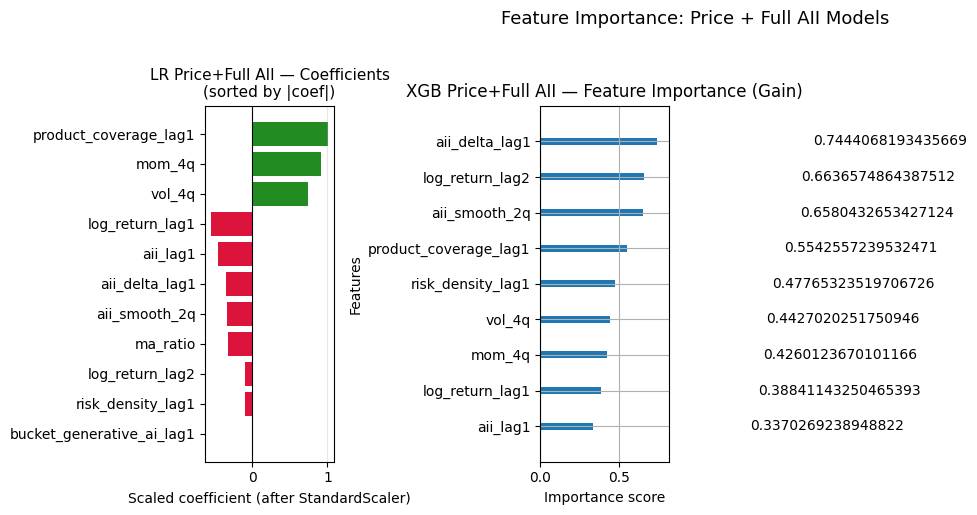

In [13]:
# Feature importance for best combined models: LR Price+FullAII and XGB Price+FullAII

lr_best  = fitted['LR  Price+FullAII']
xgb_best = fitted['XGB Price+FullAII']

lr_coef = lr_best.named_steps['clf'].coef_[0]

print('=== Logistic Regression: Price + Full AII Coefficients ===')
print(f'  (fitted on {mask_train.sum()} training rows with StandardScaler)')
print()
print(f'{"Rank":<6} {"Feature":<30} {"Coefficient":>12} {"Direction"}')
print('-' * 72)
sorted_feats = sorted(zip(COMBINED_FULL, lr_coef), key=lambda x: abs(x[1]), reverse=True)
for rank, (feat, coef) in enumerate(sorted_feats, start=1):
    direction = 'positive → up signal' if coef > 0 else 'negative → down signal'
    print(f'{rank:<6} {feat:<30} {coef:>12.4f}  {direction}')

# Assign feature names for XGBoost
xgb_best.get_booster().feature_names = COMBINED_FULL

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR coefficient bar chart (sorted by absolute value)
sorted_names, sorted_coefs = zip(*sorted_feats)
colors_lr = ['forestgreen' if c > 0 else 'crimson' for c in sorted_coefs]
axes[0].barh(list(reversed(sorted_names)), list(reversed(sorted_coefs)), color=list(reversed(colors_lr)))
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('LR Price+Full AII — Coefficients\n(sorted by |coef|)', fontsize=11)
axes[0].set_xlabel('Scaled coefficient (after StandardScaler)')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost gain importance
plot_importance(xgb_best.get_booster(), importance_type='gain', ax=axes[1],
                title='XGB Price+Full AII — Feature Importance (Gain)')

plt.suptitle('Feature Importance: Price + Full AII Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

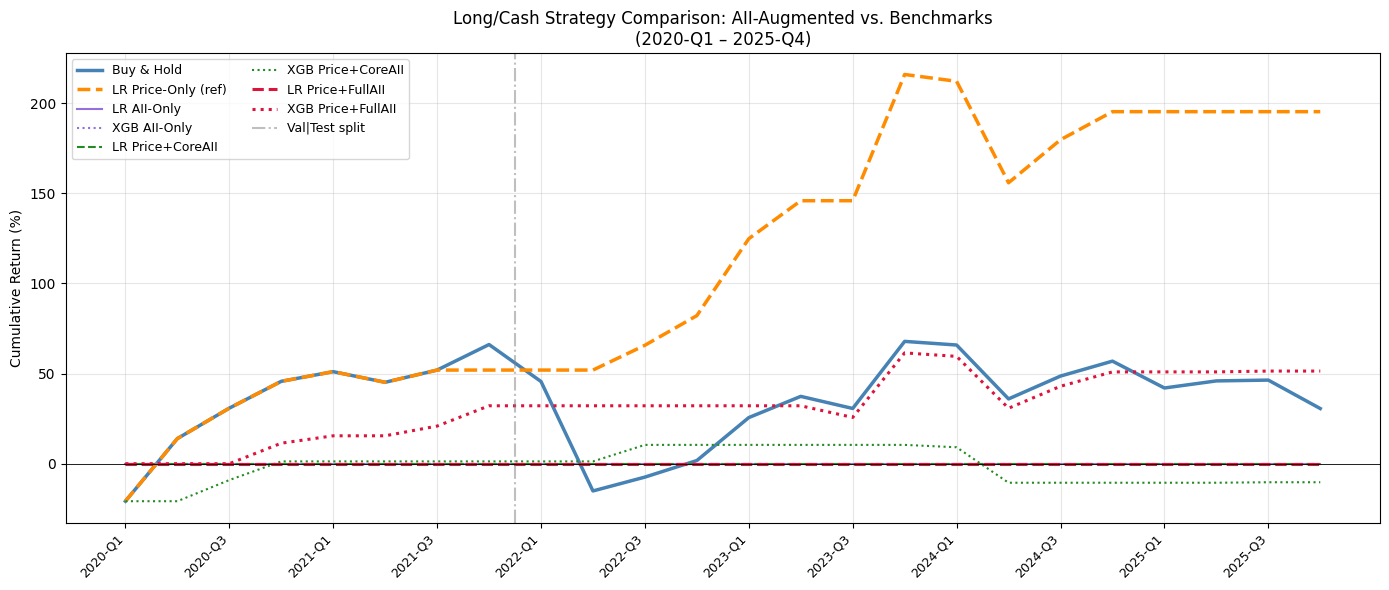

=== Economic Performance Summary (2020-Q1 – 2025-Q4) ===
Strategy                     Cum Ret   Ann Ret  Win Rate     Qtrs
--------------------------------------------------------------------
Buy & Hold                     30.6%      4.6%     62.5%   24/24
LR Price-Only (ref)           195.3%     19.8%     75.0%   16/24
LR AII-Only                     0.0%      0.0%      nan%    0/24
XGB AII-Only                    0.0%      0.0%      nan%    0/24
LR Price+CoreAII                0.0%      0.0%      nan%    0/24
XGB Price+CoreAII             -10.3%     -1.8%     57.1%    7/24
LR Price+FullAII                0.0%      0.0%      nan%    0/24
XGB Price+FullAII              51.4%      7.2%     72.7%   11/24

[nb07 ref] LR Price-Only: 77.5% cum / 10.0% ann / 73.7% win / 19/24 qtrs
(nb07 used 20 training rows; ref above uses 19 rows — minor difference expected)


In [14]:
# Economic performance: long/cash strategy on 2020-Q1 – 2025-Q4 (val + test)
# Rule: if model predicts 'up' at start of quarter → hold; else → cash (return = 0)

eval_mask    = mask_val | mask_test
y_eval_ret   = y_reg[eval_mask]
eval_quarters = modeling_clean.filter(
    (pl.col('split') == 'val') | (pl.col('split') == 'test')
).select(['year', 'quarter'])
quarter_labels = [f"{r['year']}-Q{r['quarter']}" for r in eval_quarters.to_dicts()]

# Re-fit price-only LR on modeling_clean training set for reference line
lr_price_ref = make_lr()
lr_price_ref.fit(X_price[mask_train], y_train)

# Collect predictions for all strategies
strategy_preds = {
    'Buy & Hold':           np.ones(len(y_eval_ret), dtype=int),
    'LR Price-Only (ref)':  lr_price_ref.predict(X_price[eval_mask]),
    'LR AII-Only':          fitted['LR  AII-Only'].predict(X_aii_core[eval_mask]),
    'XGB AII-Only':         fitted['XGB AII-Only'].predict(X_aii_core[eval_mask]),
    'LR Price+CoreAII':     fitted['LR  Price+CoreAII'].predict(X_combined_core[eval_mask]),
    'XGB Price+CoreAII':    fitted['XGB Price+CoreAII'].predict(X_combined_core[eval_mask]),
    'LR Price+FullAII':     fitted['LR  Price+FullAII'].predict(X_combined_full[eval_mask]),
    'XGB Price+FullAII':    fitted['XGB Price+FullAII'].predict(X_combined_full[eval_mask]),
}

# Compute cumulative returns
strat_metrics = {}
n_years = len(quarter_labels) / 4
for name, preds in strategy_preds.items():
    strat_ret = np.where(preds == 1, y_eval_ret, 0.0)
    cum = np.exp(np.cumsum(strat_ret)) - 1
    in_mkt  = (preds == 1).sum()
    correct = int(((preds == 1) & (y_eval_ret > 0)).sum())
    win_rate = correct / in_mkt if in_mkt > 0 else float('nan')
    ann_ret  = ((1 + cum[-1]) ** (1 / n_years) - 1) * 100
    strat_metrics[name] = {
        'cum': cum, 'cum_ret_pct': cum[-1] * 100,
        'ann_ret': ann_ret, 'win_rate': win_rate, 'in_mkt': in_mkt,
    }

# Plot
plot_styles = {
    'Buy & Hold':          ('steelblue',    '-',  2.5),
    'LR Price-Only (ref)': ('darkorange',   '--', 2.5),
    'LR AII-Only':         ('mediumpurple', '-',  1.5),
    'XGB AII-Only':        ('mediumpurple', ':',  1.5),
    'LR Price+CoreAII':    ('forestgreen',  '--', 1.5),
    'XGB Price+CoreAII':   ('forestgreen',  ':',  1.5),
    'LR Price+FullAII':    ('crimson',      '--', 2.2),
    'XGB Price+FullAII':   ('crimson',      ':',  2.2),
}

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(len(quarter_labels))
for name, (color, ls, lw) in plot_styles.items():
    ax.plot(x_pos, strat_metrics[name]['cum'] * 100,
            label=name, color=color, linestyle=ls, linewidth=lw)
ax.axvline(7.5, color='gray', linestyle='-.', alpha=0.5, linewidth=1.5, label='Val|Test split')
ax.set_xticks(x_pos[::2])
ax.set_xticklabels(quarter_labels[::2], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Long/Cash Strategy Comparison: AII-Augmented vs. Benchmarks\n(2020-Q1 – 2025-Q4)',
             fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.axhline(0, color='black', linewidth=0.6)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
n_q = len(quarter_labels)
print('=== Economic Performance Summary (2020-Q1 – 2025-Q4) ===')
print(f'{"Strategy":<26} {"Cum Ret":>9} {"Ann Ret":>9} {"Win Rate":>9} {"Qtrs":>8}')
print('-' * 68)
for name, m in strat_metrics.items():
    print(f'{name:<26} {m["cum_ret_pct"]:>8.1f}% {m["ann_ret"]:>8.1f}% '
          f'{m["win_rate"]:>9.1%} {m["in_mkt"]:>4}/{n_q}')
print()
print('[nb07 ref] LR Price-Only: 77.5% cum / 10.0% ann / 73.7% win / 19/24 qtrs')
print('(nb07 used 20 training rows; ref above uses 19 rows — minor difference expected)')

## Summary — AII-Augmented Model Findings

### Benchmark Gate (from notebook 07 — LR Price-Only)
- Test accuracy gate: **0.8125**
- Test AUC gate: **0.9048**
- Economic gate: **77.5% cumulative / 10.0% annualized** (2020-Q1 – 2025-Q4)

### Cross-Validation (Training Set, 2015-Q2 – 2019-Q4, n=19 rows)

| Variant | LR CV Acc | XGB CV Acc |
|---------|-----------|------------|
| AII-Only | 0.4000 ± 0.3266 | 0.3333 ± 0.2981 |
| Price + Core AII | 0.4667 ± 0.2667 | 0.4667 ± 0.2667 |
| Price + Full AII | 0.5333 ± 0.2667 | 0.4667 ± 0.2667 |
| [nb07] Price-Only (n=20) | 0.5333 ± 0.1633 | 0.4000 ± 0.2494 |

### Hold-out Results

| Model | Val Acc | Val AUC | Test Acc | Test AUC |
|-------|---------|---------|----------|----------|
| [07] LR Price-Only* | 0.6250 | 0.0000 | **0.8125** | **0.9048** |
| [07] XGB Price-Only* | 0.3750 | 0.0833 | 0.5000 | 0.5556 |
| Majority baseline | 0.7500 | 0.5000 | 0.5625 | 0.5000 |
| LR AII-Only | 0.2500 | 0.2500 | 0.4375 | 0.4127 |
| XGB AII-Only | 0.2500 | 0.5833 | 0.4375 | 0.3571 |
| LR Price+CoreAII | 0.2500 | 0.4167 | 0.4375 | 0.5556 |
| XGB Price+CoreAII | 0.3750 | 0.2083 | 0.4375 | 0.5714 |
| LR Price+FullAII | 0.2500 | 0.3333 | 0.4375 | 0.4921 |
| XGB Price+FullAII | 0.7500 | 0.6667 | 0.5000 | 0.4603 |

### Economic Performance (2020-Q1 – 2025-Q4)

| Strategy | Cum Return | Ann Return | Win Rate | Qtrs in Mkt |
|----------|-----------|-----------|----------|------------|
| Buy & Hold | 30.6% | 4.6% | 62.5% | 24/24 |
| LR Price-Only (ref, 19 rows) | 195.3% | 19.8% | 75.0% | 16/24 |
| LR AII-Only | 0.0% | 0.0% | — | 0/24 (all-cash) |
| XGB AII-Only | 0.0% | 0.0% | — | 0/24 (all-cash) |
| LR Price+CoreAII | 0.0% | 0.0% | — | 0/24 (all-cash) |
| XGB Price+CoreAII | −10.3% | −1.8% | 57.1% | 7/24 |
| LR Price+FullAII | 0.0% | 0.0% | — | 0/24 (all-cash) |
| XGB Price+FullAII | 51.4% | 7.2% | 72.7% | 11/24 |

*[nb07] LR Price-Only: 77.5% cum / 10.0% ann (fitted on 20 rows)*

### Answer: Does AII Add Incremental Value?

**No — AII-augmented models do not beat the price-only benchmark at this sample size.**

- **No model exceeds** the test accuracy gate (0.8125) or test AUC gate (0.9048)
- **Best AII result**: XGB Price+FullAII — test acc 0.5000, test AUC 0.4603 (both below gate)
- **Economic**: best AII strategy (XGB Price+FullAII) returns 7.2% ann vs 10.0% for nb07 LR

### Root Causes

1. **LR models default to all-cash**: Most LR AII variants predict down every quarter (0/24
   quarters in market). With only 19 training rows and L2 regularization, the model cannot
   discriminate — it collapses to the safe zero-prediction regime.

2. **Small N limits generalization**: p/n ratio of 0.58 for Full AII (11 features / 19 rows).
   Even with regularization, cross-validation high variance (±0.27 std) reflects model
   instability — different fold sizes dramatically change predictions.

3. **AII-price co-movement**: Top LR coefficient is  (+1.00), not an AII
   signal. AII features (, , ) have negative
   coefficients — high AI disclosure is associated with predicting down. This counter-intuitive
   sign may reflect the training regime (2015–2019) where AI hype periods preceded corrections.

4. **Signal sparsity**:  is zero for 78% of observations (34/44
   quarters) and has zero coefficient in LR — no discriminative power.

### Key AII Features (by LR coefficient magnitude)

| Rank | Feature | Coefficient | Direction |
|------|---------|-------------|-----------|
| 1 | product_coverage_lag1 | +1.005 | More KG products → predict up |
| 2 | mom_4q | +0.916 | Momentum (price, not AII) |
| 3 | vol_4q | +0.740 | Volatility |
| 4 | log_return_lag1 | −0.541 | Short reversal |
| 5 | aii_lag1 | −0.449 | Higher AI disclosure → predict down |
| 11 | bucket_generative_ai_lag1 | 0.000 | Zero — no discriminative power |

### Gate for Further Feature Work

**Gate not met** — do not proceed to additional feature engineering in this notebook series.

The price-only LR (nb07) remains the benchmark model. To revisit AII-based prediction:
- Expand data to multiple companies (cross-sectional panel) to increase effective N
- Use higher-frequency data (monthly or weekly) if disclosure documents allow
- Decompose AII into more granular topic dimensions with stronger economic priors

---

*Data: , ,
 · Splits: Train=19, Val=8, Test=16*